# Global Carbon Abatement as a Public Goods Game
### MSc Economics | Game Theory | Assignment 1

---

## Model Overview

**N** countries each choose an abatement level $a_i \geq 0$. The payoff function is:

$$\pi_i(a_i, A_{-i}) = \alpha \sum_j a_j - \frac{c_i}{2} a_i^2 = \alpha(a_i + A_{-i}) - \frac{c}{2}a_i^2$$

where $\alpha > 0$ is the per-country marginal benefit of global abatement and $c > 0$ is the marginal cost coefficient.

**Key analytical results:**

| Concept | Expression | Interpretation |
|---|---|---|
| Nash Equilibrium | $a_i^* = \alpha / c$ | Dominant strategy; independent of others' actions |
| Social Optimum | $a_i^{SO} = N\alpha / c$ | Planner internalises full externality |
| Efficiency Ratio | $a_i^* / a_i^{SO} = 1/N$ | Universal — holds regardless of $c_i$ |
| Pigouvian Subsidy | $s^* = (N-1)\alpha$ | Required per-unit transfer to restore SO |

Extended to **N = 119** to reflect the 119 NDC-submitting nations at COP30, Belém (November 2025).

## Cell 1 — Imports and Parameters

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Model parameters ──────────────────────────────────────────────────────────
alpha   = 1.0   # per-country marginal benefit of global abatement
c       = 2.0   # marginal cost coefficient (symmetric baseline)
N_COP30 = 119   # NDC-submitting nations at COP30, Belém 2025 (UNFCCC, 2025)

print(f"Parameters: α = {alpha}, c = {c}, N (COP30) = {N_COP30}")

Parameters: α = 1.0, c = 2.0, N (COP30) = 119


## Cell 2 — Core Computations: NE, SO, Welfare Loss, Pigouvian Subsidy

In [2]:
# ── Range of N from 2 to 119 ──────────────────────────────────────────────────
N_range  = np.arange(2, N_COP30 + 1)

# ── Nash Equilibrium (dominant strategy best response) ────────────────────────
# FOC: ∂πᵢ/∂aᵢ = α - c·aᵢ = 0  =>  aᵢ* = α/c  (independent of A₋ᵢ)
a_NE     = alpha / c                        # individual NE (constant in N)
total_NE = N_range * a_NE                   # aggregate NE abatement

# ── Social Optimum (planner maximises ΣᵢΠᵢ) ──────────────────────────────────
# FOC: N·α - c·aᵢ = 0  =>  aᵢˢᵒ = Nα/c
a_SO     = (N_range * alpha) / c            # individual SO (grows with N)
total_SO = N_range * a_SO                   # aggregate SO abatement

# ── Efficiency ratio: aᵢ*/aᵢˢᵒ = 1/N ─────────────────────────────────────────
efficiency = a_NE / a_SO                    # = 1/N_range

# ── Optimal Pigouvian subsidy: s* = (N-1)·α ──────────────────────────────────
s_star = (N_range - 1) * alpha

# ── Welfare (symmetric model): W = N·α·A - (c/2)·N·a² ───────────────────────
W_NE = N_range * alpha * total_NE - (c/2) * N_range * a_NE**2
W_SO = N_range * alpha * total_SO - (c/2) * N_range * a_SO**2
welfare_loss_pct = (W_SO - W_NE) / W_SO * 100

# ── COP30-specific values (N = 119) ───────────────────────────────────────────
idx_cop30 = N_COP30 - 2
wl_cop30  = welfare_loss_pct[idx_cop30]
s_cop30   = s_star[idx_cop30]

print("=" * 55)
print(f"Key Results  (α={alpha}, c={c})")
print("=" * 55)
print(f"  Individual NE abatement:        a* = {a_NE:.4f}  (constant in N)")
print(f"  Individual SO abatement N=10:        {10*alpha/c:.4f}")
print(f"  Individual SO abatement N=119:       {119*alpha/c:.4f}")
print(f"  Welfare loss at N=10:           {welfare_loss_pct[8]:.2f}%")
print(f"  Welfare loss at N=119 (COP30):  {wl_cop30:.2f}%")
print(f"  Optimal subsidy at N=119:       s* = {s_cop30:.0f}α  (11,800% uplift)")
print(f"  Efficiency ratio at N=119:      1/N = {1/119:.5f}  (0.84% of SO)")

Key Results  (α=1.0, c=2.0)
  Individual NE abatement:        a* = 0.5000  (constant in N)
  Individual SO abatement N=10:        5.0000
  Individual SO abatement N=119:       59.5000
  Welfare loss at N=10:           81.00%
  Welfare loss at N=119 (COP30):  98.33%
  Optimal subsidy at N=119:       s* = 118α  (11,800% uplift)
  Efficiency ratio at N=119:      1/N = 0.00840  (0.84% of SO)


## Cell 3 — Comparative Statics: Varying α at N = 119

In [3]:
# ── Comparative statics: vary α ∈ [0.5, 3.0], fix N = 119, c = 2 ─────────────
# ∂a^NE/∂α = 1/c > 0  (higher co-benefits raise equilibrium abatement)
# ∂a^NE/∂c = -α/c² < 0  (higher costs reduce equilibrium abatement)
# ∂s*/∂N   = α > 0  (each additional country raises required subsidy)

alpha_range  = np.linspace(0.5, 3.0, 100)
N_fix        = N_COP30
a_NE_alpha   = alpha_range / c              # NE scales linearly in α
a_SO_alpha   = N_fix * alpha_range / c      # SO scales N-times faster
s_star_alpha = (N_fix - 1) * alpha_range    # optimal subsidy vs α

print("Comparative statics computed:")
print(f"  ∂a^NE/∂α = 1/c = {1/c:.3f}  > 0")
print(f"  ∂a^NE/∂c = -α/c² = {-alpha/c**2:.3f}  < 0")
print(f"  ∂s*/∂N   = α = {alpha:.3f}  > 0")

Comparative statics computed:
  ∂a^NE/∂α = 1/c = 0.500  > 0
  ∂a^NE/∂c = -α/c² = -0.250  < 0
  ∂s*/∂N   = α = 1.000  > 0


## Cell 4 — Figure: Four-Panel Simulation Plot

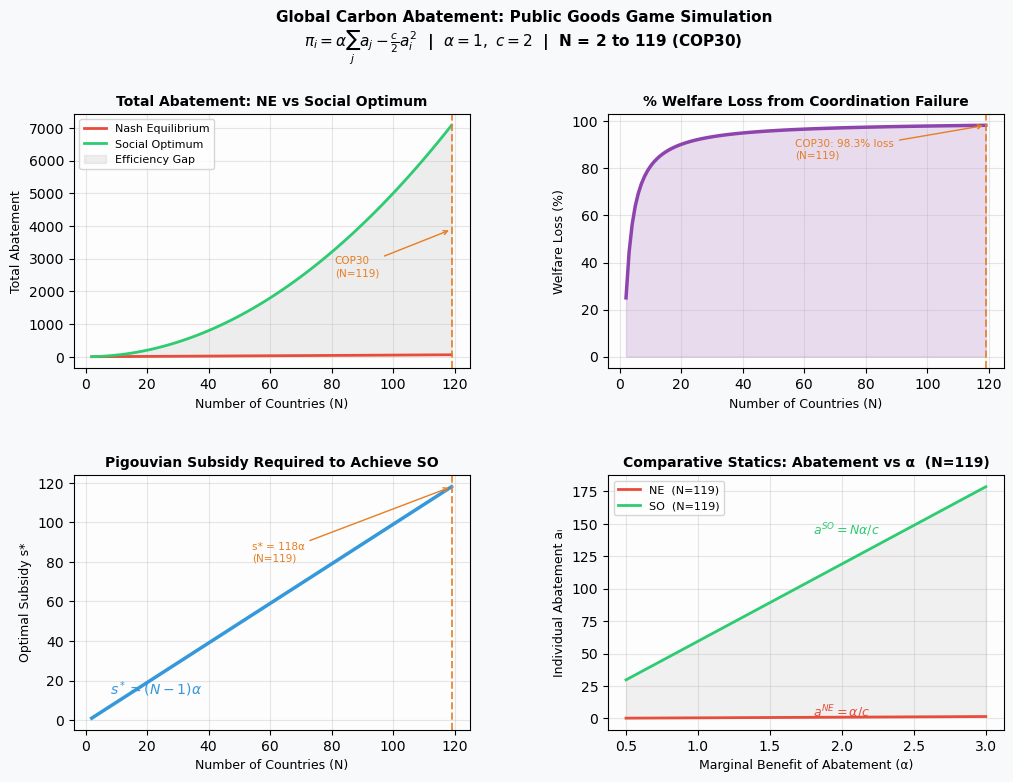

In [4]:
fig = plt.figure(figsize=(12, 8))
fig.patch.set_facecolor('#F8F9FA')
gs = gridspec.GridSpec(2, 2, hspace=0.42, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

col_NE  = '#E74C3C'
col_SO  = '#2ECC71'
col_s   = '#3498DB'
col_cop = '#E67E22'

# ── Plot 1: Total abatement NE vs SO ─────────────────────────────────────────
ax1.plot(N_range, total_NE, color=col_NE, lw=2, label='Nash Equilibrium')
ax1.plot(N_range, total_SO, color=col_SO, lw=2, label='Social Optimum')
ax1.fill_between(N_range, total_NE, total_SO, alpha=0.12, color='gray', label='Efficiency Gap')
ax1.axvline(x=N_COP30, color=col_cop, lw=1.4, linestyle='--', alpha=0.85)
ax1.annotate(f'COP30\n(N={N_COP30})', xy=(N_COP30, total_SO[idx_cop30]*0.55),
             xytext=(N_COP30-38, total_SO[idx_cop30]*0.35), fontsize=7.5, color=col_cop,
             arrowprops=dict(arrowstyle='->', color=col_cop, lw=1.0))
ax1.set_xlabel('Number of Countries (N)', fontsize=9)
ax1.set_ylabel('Total Abatement', fontsize=9)
ax1.set_title('Total Abatement: NE vs Social Optimum', fontsize=10, fontweight='bold')
ax1.legend(fontsize=8)
ax1.set_facecolor('#FDFDFD')
ax1.grid(alpha=0.3)

# ── Plot 2: Welfare loss % ────────────────────────────────────────────────────
ax2.plot(N_range, welfare_loss_pct, color='#8E44AD', lw=2.5)
ax2.fill_between(N_range, welfare_loss_pct, alpha=0.18, color='#8E44AD')
ax2.axvline(x=N_COP30, color=col_cop, lw=1.4, linestyle='--', alpha=0.85)
ax2.annotate(f'COP30: {wl_cop30:.1f}% loss\n(N={N_COP30})',
             xy=(N_COP30, wl_cop30), xytext=(N_COP30-62, wl_cop30-14),
             fontsize=7.5, color=col_cop,
             arrowprops=dict(arrowstyle='->', color=col_cop, lw=1.0))
ax2.set_xlabel('Number of Countries (N)', fontsize=9)
ax2.set_ylabel('Welfare Loss (%)', fontsize=9)
ax2.set_title('% Welfare Loss from Coordination Failure', fontsize=10, fontweight='bold')
ax2.set_facecolor('#FDFDFD')
ax2.grid(alpha=0.3)

# ── Plot 3: Pigouvian subsidy ─────────────────────────────────────────────────
ax3.plot(N_range, s_star, color=col_s, lw=2.5)
ax3.axvline(x=N_COP30, color=col_cop, lw=1.4, linestyle='--', alpha=0.85)
ax3.annotate(f's* = {s_cop30:.0f}α\n(N={N_COP30})',
             xy=(N_COP30, s_cop30), xytext=(N_COP30-65, s_cop30*0.68),
             fontsize=7.5, color=col_cop,
             arrowprops=dict(arrowstyle='->', color=col_cop, lw=1.0))
ax3.text(8, s_star[25]*0.5, r'$s^* = (N-1)\alpha$', fontsize=10, color=col_s)
ax3.set_xlabel('Number of Countries (N)', fontsize=9)
ax3.set_ylabel('Optimal Subsidy s*', fontsize=9)
ax3.set_title('Pigouvian Subsidy Required to Achieve SO', fontsize=10, fontweight='bold')
ax3.set_facecolor('#FDFDFD')
ax3.grid(alpha=0.3)

# ── Plot 4: Comparative statics ───────────────────────────────────────────────
ax4.plot(alpha_range, a_NE_alpha, color=col_NE, lw=2, label=f'NE  (N={N_fix})')
ax4.plot(alpha_range, a_SO_alpha, color=col_SO, lw=2, label=f'SO  (N={N_fix})')
ax4.fill_between(alpha_range, a_NE_alpha, a_SO_alpha, alpha=0.10, color='gray')
ax4.text(1.8, a_NE_alpha[70]*1.25, r'$a^{NE}=\alpha/c$',  fontsize=9, color=col_NE)
ax4.text(1.8, a_SO_alpha[70]*1.05, r'$a^{SO}=N\alpha/c$', fontsize=9, color=col_SO)
ax4.set_xlabel('Marginal Benefit of Abatement (α)', fontsize=9)
ax4.set_ylabel('Individual Abatement aᵢ', fontsize=9)
ax4.set_title(f'Comparative Statics: Abatement vs α  (N={N_fix})', fontsize=10, fontweight='bold')
ax4.legend(fontsize=8)
ax4.set_facecolor('#FDFDFD')
ax4.grid(alpha=0.3)

fig.suptitle(
    'Global Carbon Abatement: Public Goods Game Simulation\n'
    r'$\pi_i = \alpha\sum_j a_j - \frac{c}{2}a_i^2$  |  '
    r'$\alpha=1,\ c=2$  |  N = 2 to 119 (COP30)',
    fontsize=11, fontweight='bold', y=1.01
)


plt.show()

## Cell 5 — Pigouvian Subsidy Calibration in Dollar Terms

Setting $\alpha = \text{SCC} / N$ (equal sharing of the Social Cost of Carbon across N countries):

$$s^* = (N-1) \cdot \frac{\text{SCC}}{N} = \text{SCC} \cdot \frac{N-1}{N}$$

At N = 119, $s^* = 0.992 \times \text{SCC}$ — the required per-tonne subsidy is essentially the **full Social Cost of Carbon**.

In [5]:
# ── Calibration: s* in dollar terms ──────────────────────────────────────────
# α = SCC / N  (each country's equal share of global abatement benefit)
# s* = (N-1) × α = SCC × (N-1)/N
# At N=119: s*/SCC = 118/119 = 99.2% — required subsidy ≈ full Social Cost of Carbon

SCC_estimates = {
    'Rennert et al. (2022, Nature)': 185,
    'US EPA (2023)':                 190,
    'Stern (2022, upper bound)':     300,
}

abatement_Gt = 28   # GtCO₂eq/year required by 2035 for 1.5°C (IPCC AR6, 2022)
NCQG         = 1.3  # $tn/year (COP29/COP30 NCQG target)

print('=' * 65)
print(f'  Pigouvian Subsidy Calibration  |  N={N_COP30}  |  Abatement={abatement_Gt} GtCO2/yr')
print('=' * 65)
for source, SCC in SCC_estimates.items():
    alpha_cal = SCC / N_COP30
    s_dollar  = (N_COP30 - 1) * alpha_cal
    total_tn  = s_dollar * abatement_Gt * 1e9 / 1e12
    multiple  = total_tn / NCQG
    print(f'\n  {source}')
    print(f'    SCC            =  ${SCC}/tonne')
    print(f'    alpha = SCC/N  =  ${alpha_cal:.3f}/tonne/country')
    print(f'    s*             =  ${s_dollar:.1f}/tonne')
    print(f'    Total required =  ${total_tn:.2f} trillion/year')
    print(f'    vs NCQG $1.3tn =  {multiple:.1f}x the NCQG target')

print('\n' + '=' * 65)
print(f'  s*/SCC at N={N_COP30}: {(N_COP30-1)/N_COP30*100:.1f}%  — required subsidy ≈ full SCC')
print('=' * 65)


  Pigouvian Subsidy Calibration  |  N=119  |  Abatement=28 GtCO2/yr

  Rennert et al. (2022, Nature)
    SCC            =  $185/tonne
    alpha = SCC/N  =  $1.555/tonne/country
    s*             =  $183.4/tonne
    Total required =  $5.14 trillion/year
    vs NCQG $1.3tn =  4.0x the NCQG target

  US EPA (2023)
    SCC            =  $190/tonne
    alpha = SCC/N  =  $1.597/tonne/country
    s*             =  $188.4/tonne
    Total required =  $5.28 trillion/year
    vs NCQG $1.3tn =  4.1x the NCQG target

  Stern (2022, upper bound)
    SCC            =  $300/tonne
    alpha = SCC/N  =  $2.521/tonne/country
    s*             =  $297.5/tonne
    Total required =  $8.33 trillion/year
    vs NCQG $1.3tn =  6.4x the NCQG target

  s*/SCC at N=119: 99.2%  — required subsidy ≈ full SCC
